# STFlow — per-slide flow-matching denoiser

STFlow (Huang et al., *ICML 2025* Spotlight) models the
**joint distribution** of gene expression across an entire
slide with a spatial transformer + flow-matching denoiser.
The training set is the user's own paired Visium reference;
the trained denoiser then runs reverse-time ODE integration
on the query tiles' features + coordinates to sample
cohesive whole-slide expression patterns.

Upstream ships training scripts only — there is no released
zero-shot checkpoint. (The same group's productionised
successor, **STPath**, is the zero-shot path; see the
[STPath tutorial](t_histo_stpath.ipynb).) This wrapper
therefore runs the canonical fit-on-your-reference,
predict-on-your-query workflow on a single GPU in 5–10 min.

**When to pick STFlow over the alternatives**

| Goal | Use |
|---|---|
| Zero-shot prediction on H&E only | `stpath` |
| Per-slide fine-tune with paired Visium reference, **joint cross-spot modelling** | `stflow` — this notebook |
| Per-slide fine-tune with paired Visium reference, fast linear baseline | `hest_fm` |
| Sub-spot super-resolution on paired Visium+H&E | `istar` |

## Environment

In [1]:
import warnings
warnings.filterwarnings('ignore')

import omicverse as ov
import lazyslide as zs
ov.utils.ov_plot_set()

print('omicverse', ov.__version__, '| lazyslide', zs.__version__)

🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.2.1rc1 | lazyslide 0.9.2


## How the WSI flows through LazySlide

`ov.space.histo` wraps [LazySlide](https://github.com/RendeiroLab/LazySlide)
for tiling, FM embedding, and the `WSIData` container.
STFlow only adds the flow-matching denoiser on top:

| omicverse call | LazySlide / wsidata under the hood |
|---|---|
| `ov.space.histo.open_wsi(path)` / `read_visium_with_image` | `wsidata.open_wsi` → `WSIData` (a `SpatialData` subclass) |
| `ov.space.histo.tile(wsi, …)` | `zs.pp.find_tissues` + `zs.pp.tile_tissues` → `wsi.shapes['tiles']` |
| `ov.space.histo.embed(wsi, model='ctranspath')` | `zs.tl.feature_extraction(model='ctranspath')` → `wsi.tables['ctranspath_tiles']` |
| `ov.space.histo.predict_expression(wsi, method='stflow', reference=…)` | omicverse-specific: trains the STFlow denoiser on a tile-grid cut from the reference, runs reverse-time ODE on query tile features, writes `wsi.tables['stflow_tiles']` |

## Inputs STFlow expects

Same shape as HEST-FM — STFlow trains on the reference
slide and predicts on the query tiles:

- **`reference` — paired Visium AnnData** with `.X`,
  `.obsm['spatial']`, and
  `uns['spatial'][lib]['scalefactors']['spot_diameter_fullres']`.
- **`wsi` — `wsidata.WSIData`** wrapping the H&E. The
  query tiles are whatever you've added via
  `ov.space.histo.tile()`; the reference patches are cut
  out one-per-spot on the same WSI.
- **FM features** for both reference and query tiles, in
  `wsi.tables['{fm_backbone}_tiles']`. STFlow accepts any
  backbone (768-d CTransPath, 1280-d Virchow2, 1536-d
  GigaPath / UNI2, …) — feature dimensionality is read
  from the table; only consistency between reference and
  query matters.

For your own data:

```python
adata, wsi = ov.space.histo.read_visium_with_image(
    visium_path='/path/to/spaceranger/outs',
    image_path='/path/to/HE.tif',
)
```

## Model weights & cache layout

STFlow has **no released pretrained checkpoint** (the
authors productionised that path as STPath). It is
trained from scratch on the user's paired reference slide
every run. The only thing downloaded is the patch encoder.

| What | From | To | Size | Gated? |
|---|---|---|---|---|
| `ctranspath` patch encoder (default) | LazySlide model registry → HF `RendeiroLab/LazySlide-models-gpl` | `$HF_HOME/hub/` (default `~/.cache/huggingface/hub`) | ~100 MB | no |
| STFlow python package | git clone `Graph-and-Geometric-Learning/STFlow` | `$OV_HISTO_CACHE/STFlow/` (added to `sys.path` automatically) | ~80 MB | no |
| reference / query tile features | computed once | `$OV_HISTO_CACHE/ref_features/` and `$OV_HISTO_CACHE/tile_features/` | ~10–50 MB each | — |
| per-slide denoiser weights | trained each run | in-memory, not persisted | — | — |

`$OV_HISTO_CACHE` defaults to `~/.cache/omicverse/histo`;
override with `OV_HISTO_CACHE=/some/path` (recommended on
HPC: point it at scratch). `$HF_HOME` defaults to
`~/.cache/huggingface`; override with `HF_HOME=/some/path`.

On first import omicverse also applies a tiny patch to
upstream `stflow/model/transformer.py` (the upstream
`GeneUpdate.__init__` doesn't accept a `non_negative=`
kwarg that the caller passes — a known upstream bug). This
keeps subsequent re-clones idempotent.

**Swapping to a gated backbone** — set
`fm_backbone='uni2'` / `'gigapath'` / `'virchow2'` once
you have HuggingFace access. Quality usually improves;
training time is unchanged.

## Load the demo dataset and tile / embed

This tutorial uses **CTransPath** (768-d, all-public) so it runs without HuggingFace gating. Swap in `'gigapath'`, `'uni2'`, or `'virchow2'` for higher accuracy once you have access.

In [2]:
adata, wsi = ov.space.histo.load_breast()
ov.space.histo.tile(wsi, tile_px=224, mpp=0.5)
ov.space.histo.embed(wsi, model='ctranspath',
                     batch_size=16, num_workers=0)
print('tiles:', len(wsi.shapes['tiles']),
      '| feature table:', list(wsi.tables))

tiles: 1426 | feature table: ['ctranspath_tiles']


## Train STFlow on the reference, predict on the query

`predict_expression(method='stflow', …)` does the following:

1. on first use, auto-clones the upstream STFlow repo into
   `$OV_HISTO_CACHE/STFlow/` and adds it to `sys.path`,
2. picks `n_top_genes` HVGs on the reference (or uses the
   panel you pass via `genes=`),
3. builds a small spatial-transformer denoiser, sized by
   `n_layers` / `hidden_dim` / `n_neighbors`,
4. trains it for `n_epochs` iterations with AdamW on the
   reference (one forward pass = the whole slide; very
   cheap per epoch),
5. runs `n_sample_steps` Euler integration steps of the
   reverse-time ODE on the **query** tiles to draw a sample
   from the conditional distribution `p(expression | image,
   coords)`,
6. wraps predictions as `wsi.tables['stflow_tiles']`.

### Key parameters

- `reference` — paired Visium AnnData (required).
- `fm_backbone='ctranspath'` — any registered pathology FM.
- `genes=None` — explicit panel; defaults to top-500 HVGs.
- `n_epochs=80` — training iterations. The paper trains for
  thousands of epochs over a multi-slide cohort; 80 is a
  practical demo budget that still gives meaningful
  predictions.
- `n_layers=4` — depth of the spatial transformer denoiser.
- `n_neighbors=8` — number of spatial neighbours each tile
  attends to.
- `n_sample_steps=5` — Euler steps for the reverse-time
  ODE (paper default).
- `hidden_dim=256`, `batch_size=1` — denoiser sizing.

**Gene panel size is fixed at 50** — STFlow's upstream
transformer (`stflow/model/transformer.py:63`) hardcodes a
`+50` term in the attention-MLP input dim, so the panel
must be exactly 50 genes. Leave `genes=None` to use the
top-50 HVGs from the reference, or pass an explicit
50-gene list.

### Pre-staging the patch-encoder weights

STFlow has no released checkpoint of its own (it trains
per-slide); the only thing downloaded is the patch encoder
you choose via `fm_backbone`. To run **air-gapped** or with
a vetted local checkpoint:

```python
pred = ov.space.histo.predict_expression(
    wsi, method='stflow', reference=adata,
    fm_backbone='ctranspath',
    fm_weight_path='/scratch/weights/ctranspath.pth',
    cache_dir='/scratch/omicverse_histo',
)
```

**Compute** — at the default settings the cell below takes
roughly 5–10 min on an H100; most of the time is the
ctranspath embed of the reference spot grid (cached for
re-runs).

In [3]:
pred = ov.space.histo.predict_expression(
    wsi,
    method='stflow',
    reference=adata,
    fm_backbone='ctranspath',
    n_epochs=80,
    n_layers=4,
    n_neighbors=8,
    n_sample_steps=5,
)
pred

AnnData object with n_obs × n_vars = 1426 × 50
    obs: 'tile_id', 'library_id'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'histo'
    obsm: 'spatial'

## Reading the output

`pred` is an `AnnData` whose rows are query tiles and whose
columns are the predicted gene panel:

- `pred.X` (n_tiles × n_genes) — log1p predicted expression
- `pred.var_names` — gene symbols (the 500-HVG panel by
  default, or whatever you passed in `genes=`)
- `pred.obsm['spatial']` — tile pixel centroids
- `pred.uns['histo']` — run metadata (`method`,
  `fm_backbone`, `n_epochs`, `n_layers`, `n_sample_steps`).

In [4]:
print('shape       :', pred.shape)
print('first 5 vars:', list(pred.var_names[:5]))
print('coords range:', pred.obsm['spatial'].min(0), '→',
                       pred.obsm['spatial'].max(0))
print('metadata    :', pred.uns['histo'])

shape       : (1426, 50)
first 5 vars: ['ACKR1', 'CFHR1', 'IGKC', 'ANKRD44-IT1', 'ADAMTS9-AS2']
coords range: [4468.5 4355.5] → [22223.5 23521.5]
metadata    : {'method': 'stflow', 'fm_backbone': 'ctranspath', 'n_epochs': 80, 'n_layers': 4, 'n_sample_steps': 5}


## Visualise

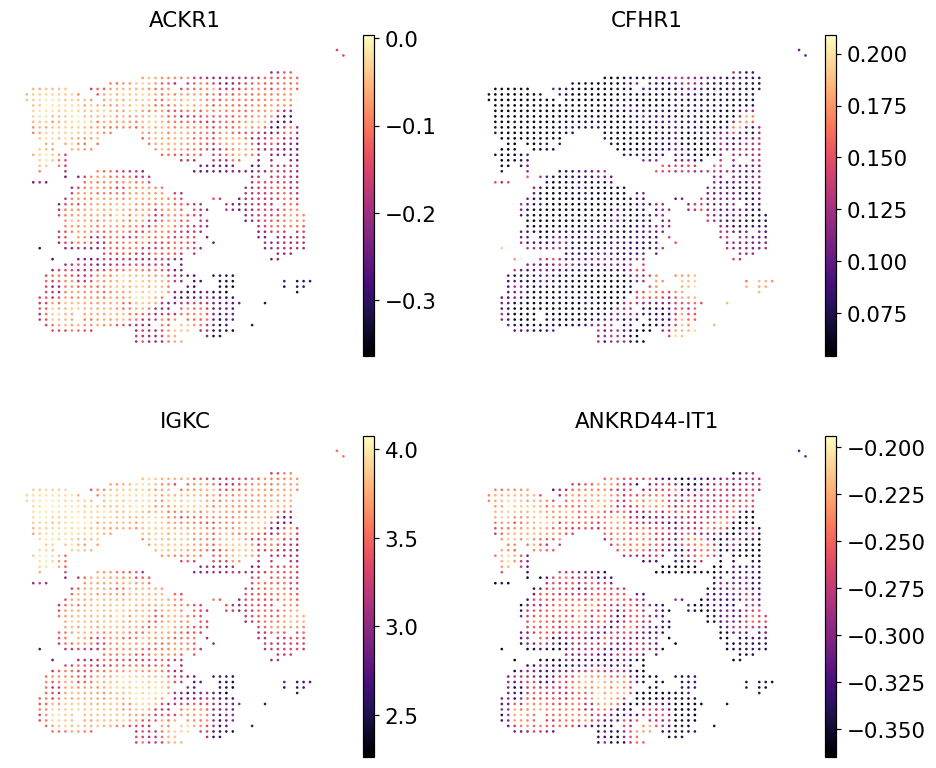

In [5]:
import scanpy as sc
sc.pl.embedding(pred, basis='spatial',
                color=list(pred.var_names[:4]),
                cmap='magma', s=12, ncols=2, frameon=False)

### Real Visium counts for the same genes

Plot the same four predicted genes from the paired Visium reference. The reference is log1p-normalised so the colour scale lines up with the STFlow output.

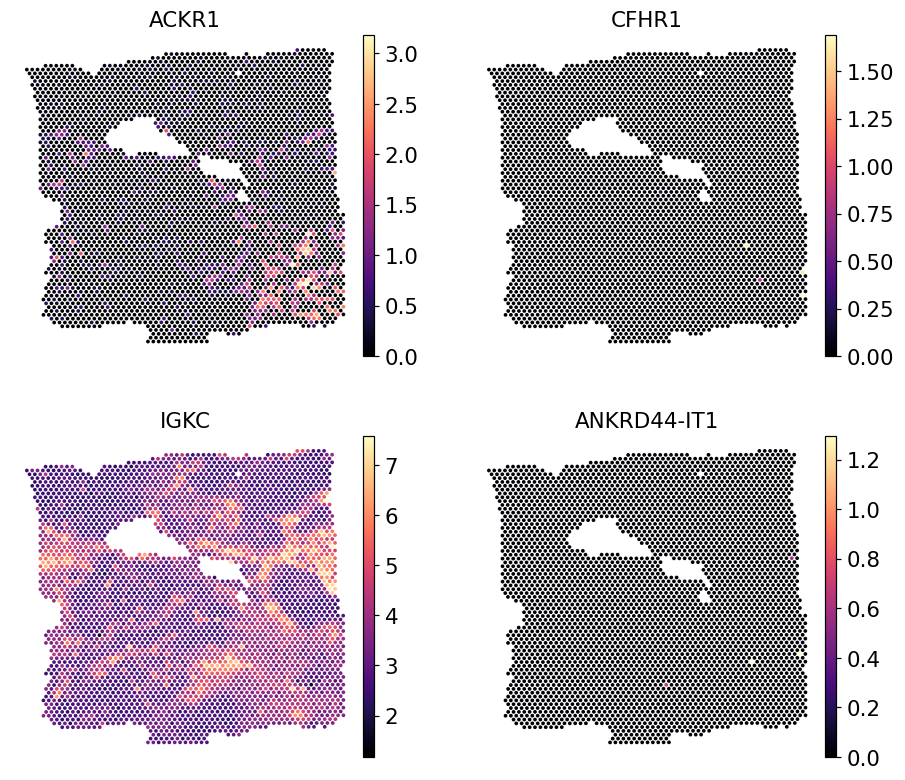

In [6]:
import scanpy as sc
ref = adata.copy()
sc.pp.normalize_total(ref, target_sum=1e4)
sc.pp.log1p(ref)
sc.pl.embedding(ref, basis='spatial',
                color=list(pred.var_names[:4]),
                cmap='magma', s=24, ncols=2, frameon=False)

## Where to go next

Just like the other HE-zoo backends, the predicted AnnData
slots straight into `ov.space.pySTAGATE`, `ov.space.svg`,
and friends. For a head-to-head on the same H&E, see
[STPath](t_histo_stpath.ipynb),
[HEST-FM](t_histo_hest_fm.ipynb), and
[iStar](t_histo_istar.ipynb).